In [1]:
! pip install -q pytorchvideo transformers evaluate
!pip install torchvision==0.13.1
!pip install pytorchvideo==0.1.5

In [2]:
from huggingface_hub import hf_hub_download
import os 
import matplotlib.pyplot as plt
import cv2
import pytorchvideo.data
import seaborn as sns
import wandb
from sklearn.metrics import roc_auc_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    log_loss,
    cohen_kappa_score,
    average_precision_score,
    matthews_corrcoef,
    balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize
import numpy as np
wandb.login(key="97c0d73ce3f332743f73aed9bfd6ffb011ebafb4")
from pytorchvideo.transforms import (
    ApplyTransformToKey,
    Normalize,
    RandomShortSideScale,
    RemoveKey,
    ShortSideScale,
    UniformTemporalSubsample,
)

from torchvision.transforms import (
    Compose,
    Lambda,
    RandomCrop,
    RandomHorizontalFlip,
    Resize,
)

import random
%matplotlib inline

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: jarif. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


In [3]:
hf_dataset_identifier = "sayakpaul/ucf101-subset"
filename = "UCF101_subset.tar.gz"
file_path = hf_hub_download(repo_id=hf_dataset_identifier, filename=filename, repo_type="dataset")

In [4]:
import tarfile

with tarfile.open(file_path) as t:
     t.extractall(".")

# Visualize Videos From Train Data

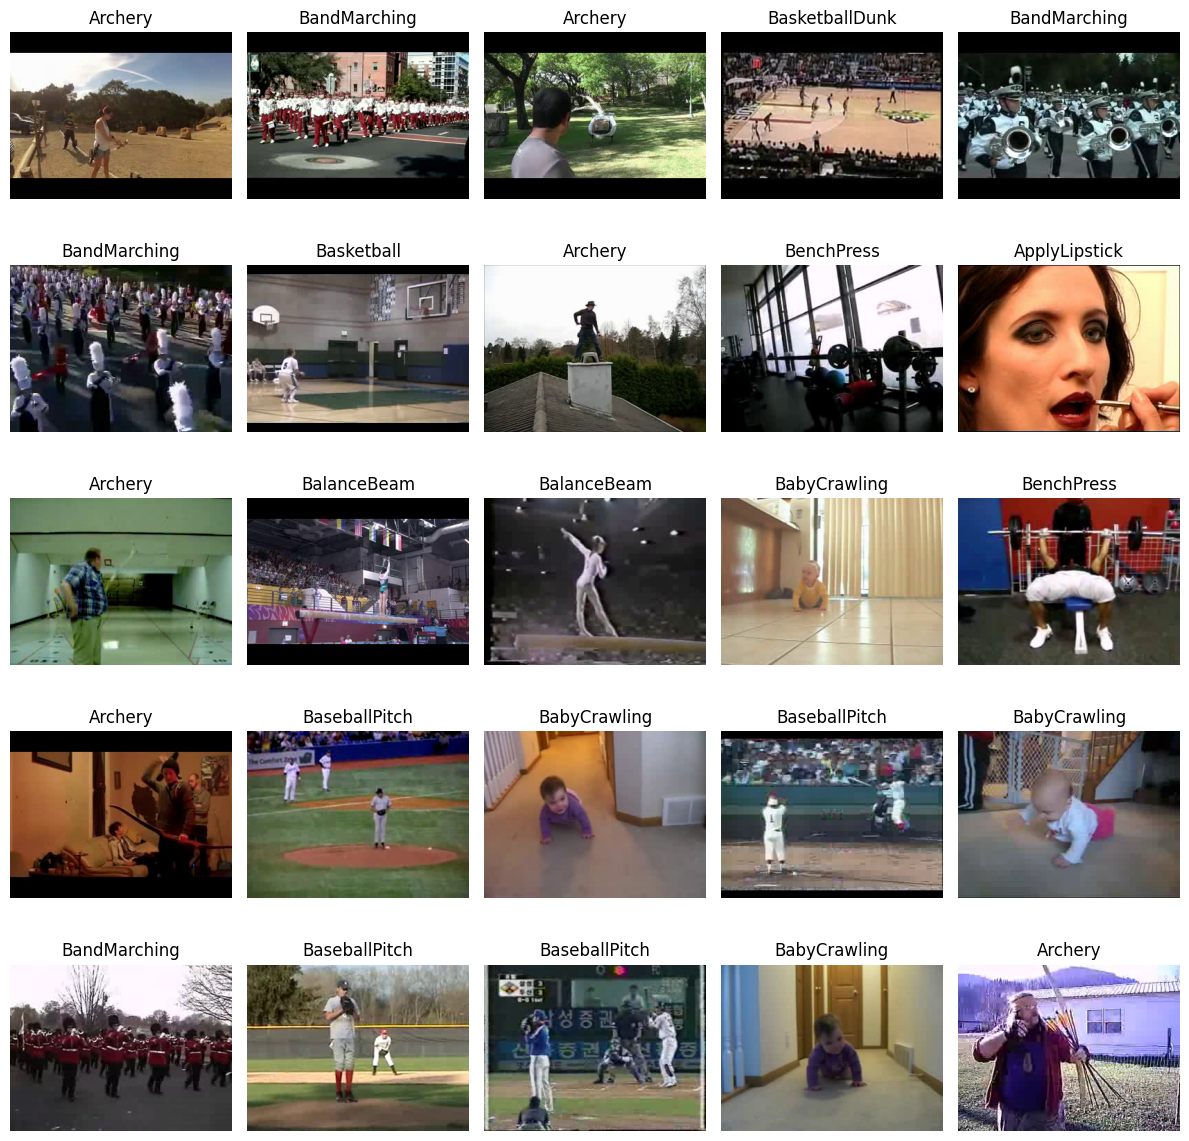

In [5]:


train_path = "/kaggle/working/UCF101_subset/train/"

def get_video_frame(video_path):
    cap = cv2.VideoCapture(video_path)
    success, frame = cap.read()
    cap.release()
    if success:
        return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return None

def get_video_label(video_path):
    return os.path.basename(os.path.dirname(video_path))

video_files = []
labels = []
for root, dirs, files in os.walk(train_path):
    for file in files:
        if file.endswith(".avi"):
            video_files.append(os.path.join(root, file))
            labels.append(get_video_label(os.path.join(root, file)))

random_indices = random.sample(range(len(video_files)), min(25, len(video_files)))

plt.figure(figsize=(12, 12))
for i, idx in enumerate(random_indices):
    frame = get_video_frame(video_files[idx])
    if frame is not None:
        plt.subplot(5, 5, i + 1)
        plt.imshow(frame)
        plt.title(f"{labels[idx]}")
        plt.axis("off")

plt.tight_layout()
plt.show()


# Visualize Videos From Valid Data

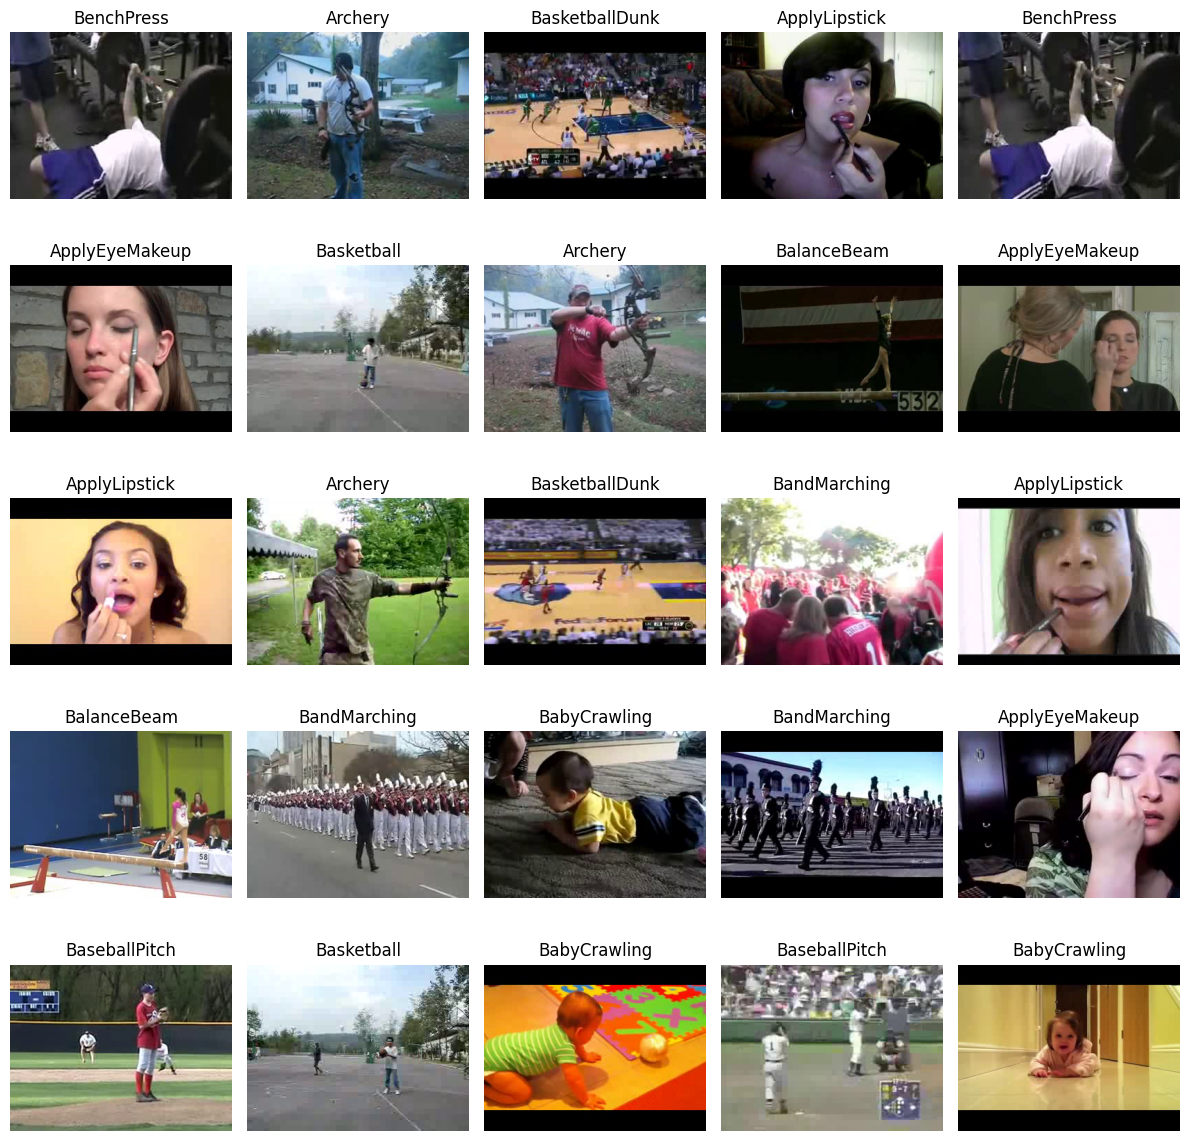

In [6]:
valid_path = "/kaggle/working/UCF101_subset/val/"

def get_video_frame(video_path):
    cap = cv2.VideoCapture(video_path)
    success, frame = cap.read()
    cap.release()
    if success:
        return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return None

def get_video_label(video_path):
    return os.path.basename(os.path.dirname(video_path))

video_files = []
labels = []
for root, dirs, files in os.walk(valid_path):
    for file in files:
        if file.endswith(".avi"):
            video_files.append(os.path.join(root, file))
            labels.append(get_video_label(os.path.join(root, file)))

random_indices = random.sample(range(len(video_files)), min(25, len(video_files)))

plt.figure(figsize=(12, 12))
for i, idx in enumerate(random_indices):
    frame = get_video_frame(video_files[idx])
    if frame is not None:
        plt.subplot(5, 5, i + 1)
        plt.imshow(frame)
        plt.title(f"{labels[idx]}")
        plt.axis("off")

plt.tight_layout()
plt.show()


In [7]:
test_path="/kaggle/working/UCF101_subset/test"
label_name=os.listdir(test_path)
print(f"Class Names : {label_name}")
print("#################################################################################################")
print("Length of Label :",len(label_name))

Class Names : ['BenchPress', 'BabyCrawling', 'ApplyLipstick', 'Archery', 'BalanceBeam', 'BandMarching', 'Basketball', 'BaseballPitch', 'BasketballDunk', 'ApplyEyeMakeup']
#################################################################################################
Length of Label : 10


# Class Length

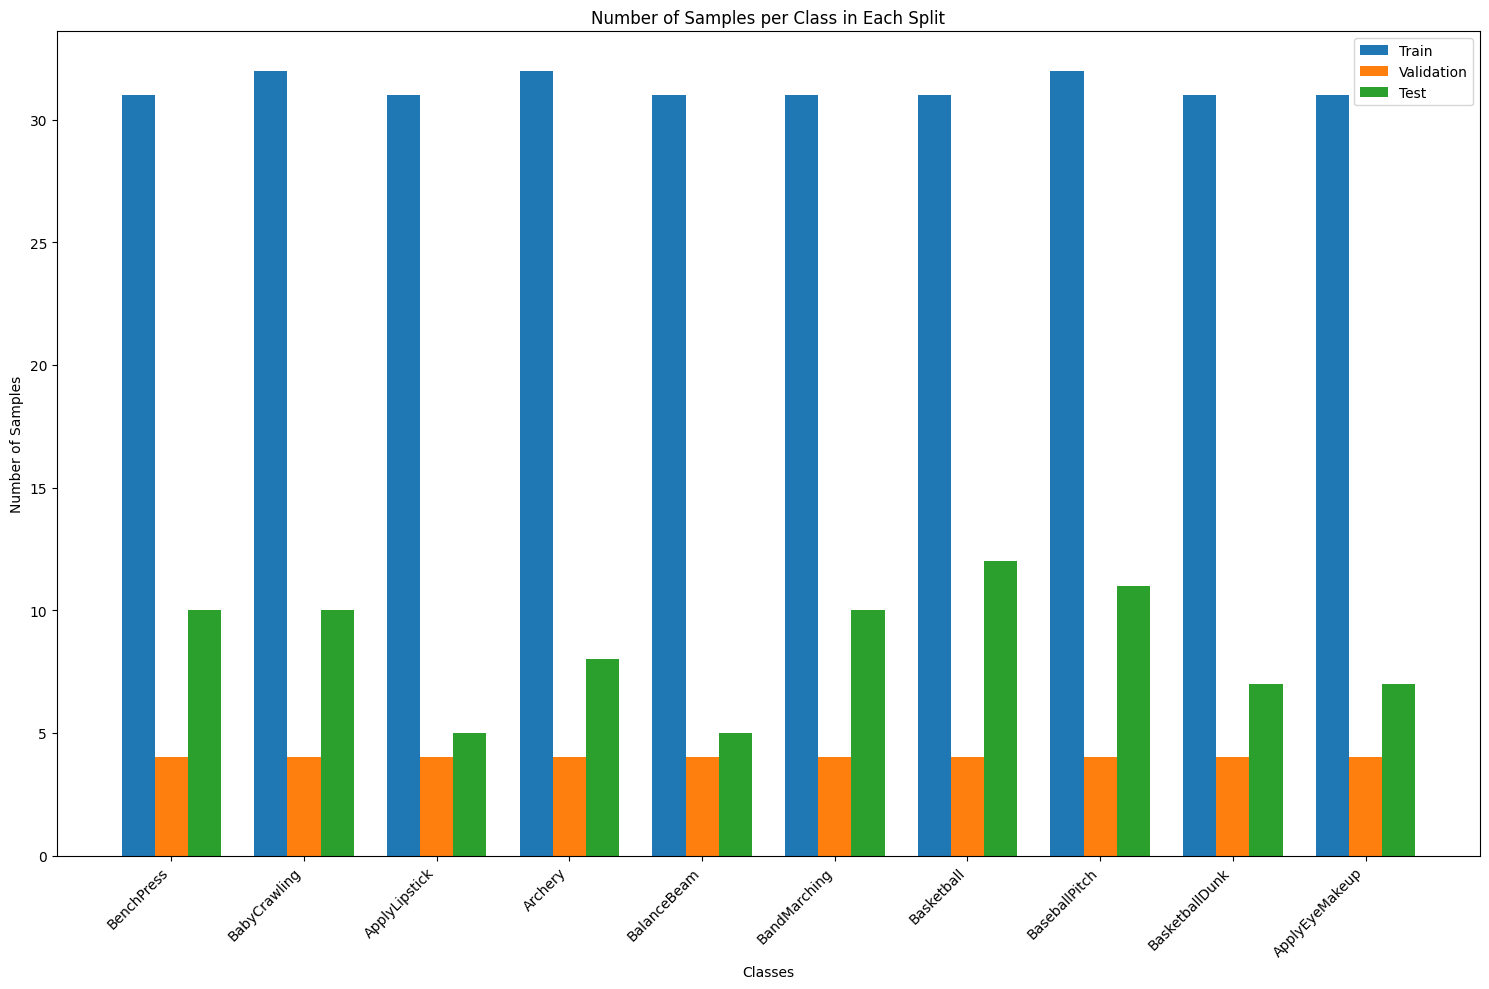


Class distribution:
BenchPress:
  Train: 31
  Validation: 4
  Test: 10
BabyCrawling:
  Train: 32
  Validation: 4
  Test: 10
ApplyLipstick:
  Train: 31
  Validation: 4
  Test: 5
Archery:
  Train: 32
  Validation: 4
  Test: 8
BalanceBeam:
  Train: 31
  Validation: 4
  Test: 5
BandMarching:
  Train: 31
  Validation: 4
  Test: 10
Basketball:
  Train: 31
  Validation: 4
  Test: 12
BaseballPitch:
  Train: 32
  Validation: 4
  Test: 11
BasketballDunk:
  Train: 31
  Validation: 4
  Test: 7
ApplyEyeMakeup:
  Train: 31
  Validation: 4
  Test: 7


In [8]:

# Get class lengths for each split
train_classes = {cls: len(os.listdir(os.path.join(train_path, cls))) for cls in os.listdir(train_path)}
val_classes = {cls: len(os.listdir(os.path.join(valid_path, cls))) for cls in os.listdir(valid_path)}
test_classes = {cls: len(os.listdir(os.path.join(test_path, cls))) for cls in os.listdir(test_path)}

# Create bar plot
plt.figure(figsize=(15, 10))
x = range(len(train_classes))
plt.bar(x, train_classes.values(), width=0.25, label='Train', align='edge')
plt.bar([i+0.25 for i in x], val_classes.values(), width=0.25, label='Validation', align='edge')
plt.bar([i+0.5 for i in x], test_classes.values(), width=0.25, label='Test', align='edge')

plt.title('Number of Samples per Class in Each Split')
plt.xlabel('Classes')
plt.ylabel('Number of Samples')
plt.legend()

plt.xticks([i+0.375 for i in x], list(train_classes.keys()), rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print class distribution
print("\nClass distribution:")
for cls in train_classes:
   print(f"{cls}:")
   print(f"  Train: {train_classes[cls]}")
   print(f"  Validation: {val_classes[cls]}")
   print(f"  Test: {test_classes[cls]}")

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


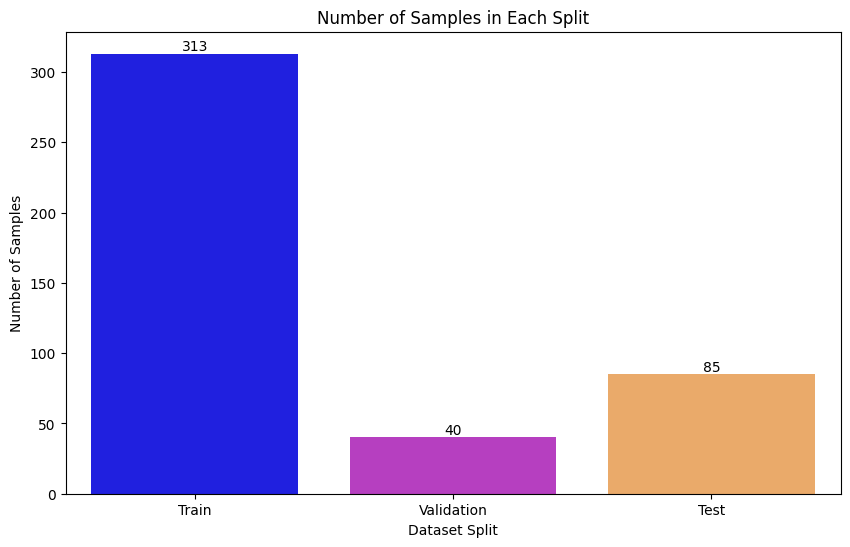


Detailed counts:
Train: 313 samples
Validation: 40 samples
Test: 85 samples


In [9]:


data_counts = {
   'Train': sum(len(os.listdir(os.path.join(train_path, cls))) for cls in os.listdir(train_path)),
   'Validation': sum(len(os.listdir(os.path.join(valid_path, cls))) for cls in os.listdir(valid_path)),
   'Test': sum(len(os.listdir(os.path.join(test_path, cls))) for cls in os.listdir(test_path))
}

plt.figure(figsize=(10, 6))
sns.barplot(x=list(data_counts.keys()), y=list(data_counts.values()),palette="gnuplot2")
plt.title('Number of Samples in Each Split')
plt.xlabel('Dataset Split')
plt.ylabel('Number of Samples')

for i, v in enumerate(data_counts.values()):
   plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

print("\nDetailed counts:")
for split, count in data_counts.items():
   print(f"{split}: {count} samples")

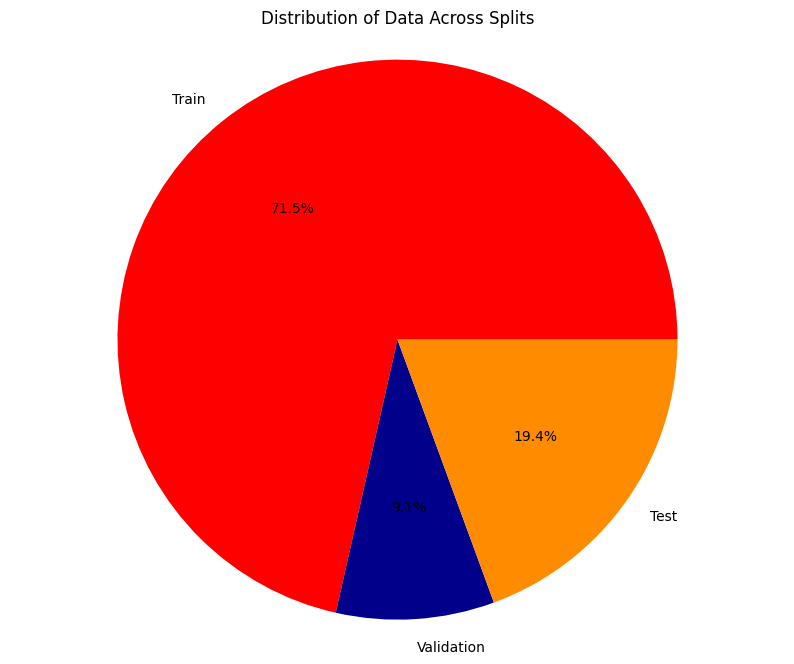

In [10]:
plt.figure(figsize=(10, 8))
color=["red","darkblue","darkorange","cyan"]
plt.pie(data_counts.values(), labels=data_counts.keys(), autopct='%1.1f%%',colors=color)
plt.title('Distribution of Data Across Splits')
plt.axis('equal')
plt.show()

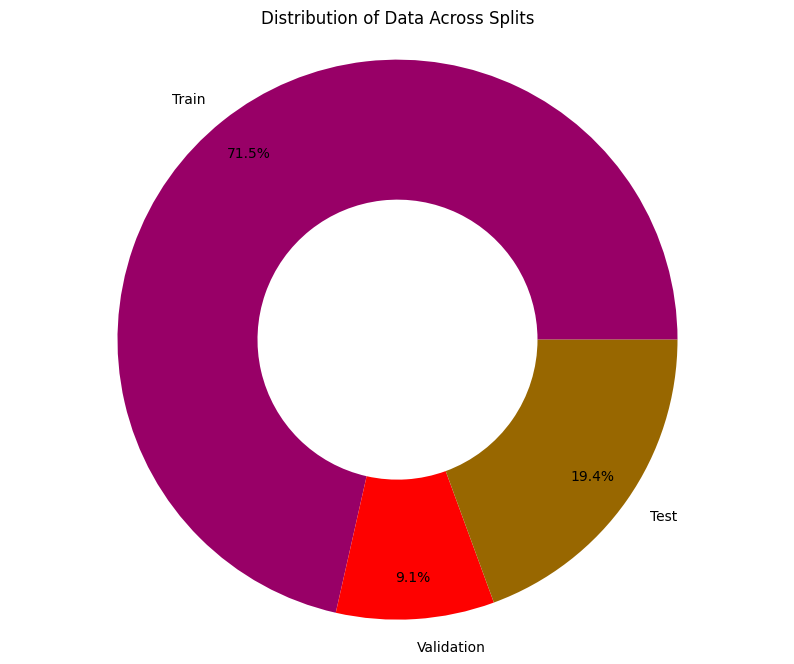

In [11]:
plt.figure(figsize=(10, 8))
colors = plt.cm.brg([0.3, 0.5, 0.7]) 
plt.pie(data_counts.values(), labels=data_counts.keys(), autopct='%1.1f%%', 
       pctdistance=0.85, wedgeprops=dict(width=0.5),colors=colors)
plt.title('Distribution of Data Across Splits')
plt.axis('equal')
plt.show()

In [12]:
import pathlib
dataset_root_path = "/kaggle/working/UCF101_subset/"
dataset_root_path = pathlib.Path(dataset_root_path)

In [13]:
video_count_train = len(list(dataset_root_path.glob("train/*/*.avi")))
video_count_val = len(list(dataset_root_path.glob("val/*/*.avi")))
video_count_test = len(list(dataset_root_path.glob("test/*/*.avi")))
video_total = video_count_train + video_count_val + video_count_test
print(f"Total videos: {video_total}")

Total videos: 405


In [14]:
all_video_file_paths = (
    list(dataset_root_path.glob("train/*/*.avi"))
    + list(dataset_root_path.glob("val/*/*.avi"))
    + list(dataset_root_path.glob("test/*/*.avi"))
 )
all_video_file_paths[:5]

[PosixPath('/kaggle/working/UCF101_subset/train/BenchPress/v_BenchPress_g07_c04.avi'),
 PosixPath('/kaggle/working/UCF101_subset/train/BenchPress/v_BenchPress_g22_c01.avi'),
 PosixPath('/kaggle/working/UCF101_subset/train/BenchPress/v_BenchPress_g06_c01.avi'),
 PosixPath('/kaggle/working/UCF101_subset/train/BenchPress/v_BenchPress_g07_c02.avi'),
 PosixPath('/kaggle/working/UCF101_subset/train/BenchPress/v_BenchPress_g02_c01.avi')]

* label2id: maps the class names to integers.
* id2label: maps the integers to class names.

In [15]:

class_labels = sorted({path.parts[-2] for path in all_video_file_paths})
label2id = {label: i for i, label in enumerate(class_labels)}
id2label = {i: label for label, i in label2id.items()}

In [16]:
print(f"Unique classes: {list(label2id.keys())}.")


Unique classes: ['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BaseballPitch', 'Basketball', 'BasketballDunk', 'BenchPress'].


# Load a model to fine-tune

In [17]:
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification

model_ckpt = "MCG-NJU/videomae-base"
image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)

Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Use the image_processor associated with the pre-trained model to obtain the following information:

* Image mean and standard deviation with which the video frame pixels will be normalized.
* Spatial resolution to which the video frames will be resized.


In [18]:
mean = image_processor.image_mean
std = image_processor.image_std
if "shortest_edge" in image_processor.size:
    height = width = image_processor.size["shortest_edge"]
else:
    height = image_processor.size["height"]
    width = image_processor.size["width"]
resize_to = (height, width)

num_frames_to_sample = model.config.num_frames
sample_rate = 4
fps = 30
clip_duration = num_frames_to_sample * sample_rate / fps

In [19]:
from pytorchvideo.transforms import (
    ApplyTransformToKey,
    UniformTemporalSubsample,
    Normalize,
    RandomShortSideScale,
)

In [20]:

train_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    RandomShortSideScale(min_size=256, max_size=320),
                    RandomCrop(resize_to),
                    RandomHorizontalFlip(p=0.5),
                ]
            ),
        ),
    ]
)

train_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(dataset_root_path, "train"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("random", clip_duration),
    decode_audio=False,
    transform=train_transform,
)

In [21]:
val_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    Resize(resize_to),
                ]
            ),
        ),
    ]
)

val_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(dataset_root_path, "val"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
    decode_audio=False,
    transform=val_transform,
)

test_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(dataset_root_path, "test"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
    decode_audio=False,
    transform=val_transform,
)

In [22]:
print(train_dataset.num_videos, val_dataset.num_videos, test_dataset.num_videos)

303 30 75


# Visualize the preprocessed video for better debugging

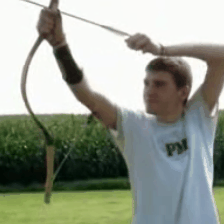

In [23]:
import imageio
import numpy as np
from IPython.display import Image

def unnormalize_img(img):
    """Un-normalizes the image pixels."""
    img = (img * std) + mean
    img = (img * 255).astype("uint8")
    return img.clip(0, 255)

def create_gif(video_tensor, filename="sample.gif"):
    """Prepares a GIF from a video tensor.
    The video tensor is expected to have the following shape:
    (num_frames, num_channels, height, width).
    """
    frames = []
    for video_frame in video_tensor:
        frame_unnormalized = unnormalize_img(video_frame.permute(1, 2, 0).numpy())
        frames.append(frame_unnormalized)
    kargs = {"duration": 0.25}
    imageio.mimsave(filename, frames, "GIF", **kargs)
    return filename

def display_gif(video_tensor, gif_name="sample.gif"):
    """Prepares and displays a GIF from a video tensor."""
    video_tensor = video_tensor.permute(1, 0, 2, 3)
    gif_filename = create_gif(video_tensor, gif_name)
    return Image(filename=gif_filename)

sample_video = next(iter(train_dataset))
video_tensor = sample_video["video"]
display_gif(video_tensor)

# Train the model

In [24]:
from transformers import TrainingArguments, Trainer

model_name = model_ckpt.split("/")[-1]
new_model_name = f"{model_name}-finetuned-ucf101-subset"
num_epochs = 2
batch_size=2

args = TrainingArguments(
    new_model_name,
    remove_unused_columns=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    warmup_ratio=0.1,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False,
    num_train_epochs=num_epochs,
    max_steps=(train_dataset.num_videos // batch_size) * num_epochs,
    gradient_accumulation_steps=4, max_grad_norm=1.0,fp16=True
)

In [25]:
import evaluate
import torch

metric = evaluate.load("accuracy")


def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

**In the VideoMAE paper, the authors use the following evaluation strategy. They evaluate the model on several clips from test videos and apply different crops to those clips and report the aggregate score. However, in the interest of simplicity and brevity, we don’t consider that in this tutorial.**

**Also, define a collate_fn, which will be used to batch examples together. Each batch consists of 2 keys, namely pixel_values and labels.**

In [26]:
def collate_fn(examples):
    # permute to (num_frames, num_channels, height, width)
    pixel_values = torch.stack(
        [example["video"].permute(1, 0, 2, 3) for example in examples]
    )
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [27]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=image_processor,  # Use tokenizer instead of processing_class
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

max_steps is given, it will override any value given in num_train_epochs


# Train Model

In [28]:
train_results = trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


Epoch,Training Loss,Validation Loss,Accuracy
0,2.281800,2.133189,0.185714
1,1.250400,1.185355,0.471429
2,0.589800,0.577978,0.771429
3,0.285800,0.516098,0.842857
4,0.196100,0.176625,0.971429
5,0.067800,0.171604,0.957143
6,0.032900,0.263563,0.900000
7,0.019500,0.055649,0.971429


In [29]:

save_dir = "/kaggle/working/video_classifier_new"
os.makedirs(save_dir, exist_ok=True)
trainer.save_model(save_dir)  


In [30]:
# import shutil

# # Zip the model directory
# shutil.make_archive('/kaggle/working/video_classifier_new', 'zip', save_dir)


In [31]:
import os

output_dir = "/kaggle/working/video_classifier"
os.makedirs(output_dir, exist_ok=True)

trainer.save_model(output_dir)
torch.save(model.state_dict(), os.path.join(output_dir, "model_weights.pth"))

from transformers import VideoMAEForVideoClassification

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loaded_model = VideoMAEForVideoClassification.from_pretrained(output_dir)
loaded_model = loaded_model.to(device)
loaded_model.eval()

VideoMAEForVideoClassification(
  (videomae): VideoMAEModel(
    (embeddings): VideoMAEEmbeddings(
      (patch_embeddings): VideoMAEPatchEmbeddings(
        (projection): Conv3d(3, 768, kernel_size=(2, 16, 16), stride=(2, 16, 16))
      )
    )
    (encoder): VideoMAEEncoder(
      (layer): ModuleList(
        (0): VideoMAELayer(
          (attention): VideoMAEAttention(
            (attention): VideoMAESelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): VideoMAESelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): VideoMAEIntermediate(
            (dense): Linear(in_f

# Confusion Matrix

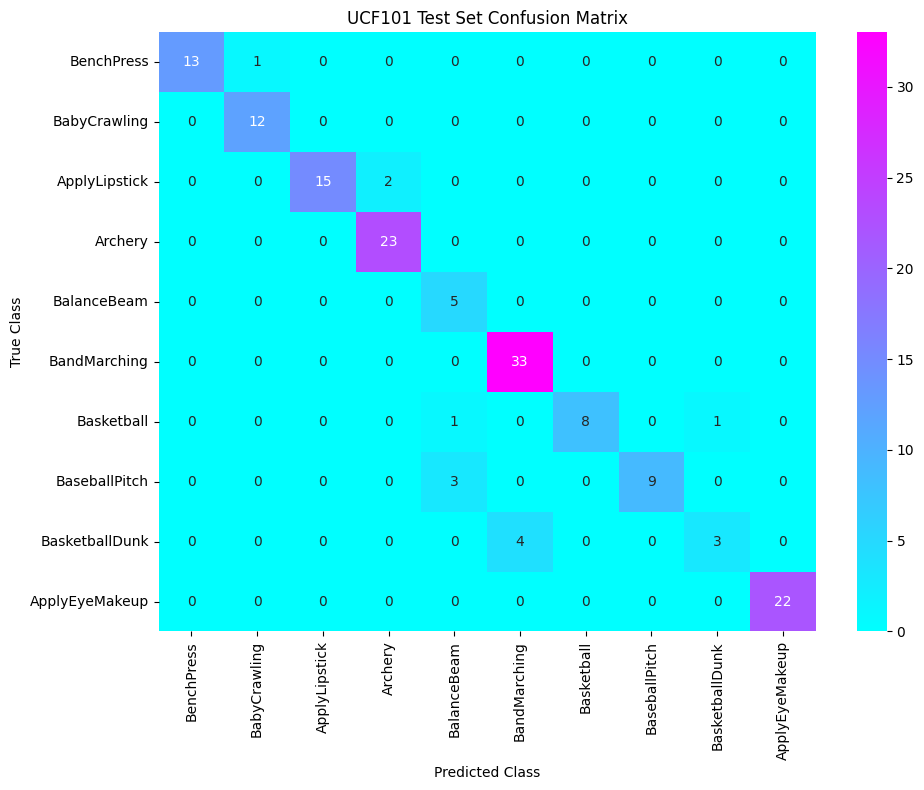

In [32]:
test_results = trainer.predict(test_dataset)
predictions = test_results.predictions
predicted_class = predictions.argmax(axis=-1)
true_labels = test_results.label_ids
pred_probs = predictions
cm = confusion_matrix(true_labels, predicted_class)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='cool',xticklabels=label_name,yticklabels=label_name)
plt.title('UCF101 Test Set Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()


# Classification Report

In [33]:

print(classification_report(true_labels,predicted_class,target_names=label_name))

                precision    recall  f1-score   support

    BenchPress       1.00      0.93      0.96        14
  BabyCrawling       0.92      1.00      0.96        12
 ApplyLipstick       1.00      0.88      0.94        17
       Archery       0.92      1.00      0.96        23
   BalanceBeam       0.56      1.00      0.71         5
  BandMarching       0.89      1.00      0.94        33
    Basketball       1.00      0.80      0.89        10
 BaseballPitch       1.00      0.75      0.86        12
BasketballDunk       0.75      0.43      0.55         7
ApplyEyeMakeup       1.00      1.00      1.00        22

      accuracy                           0.92       155
     macro avg       0.90      0.88      0.88       155
  weighted avg       0.93      0.92      0.92       155



# Roc Curve

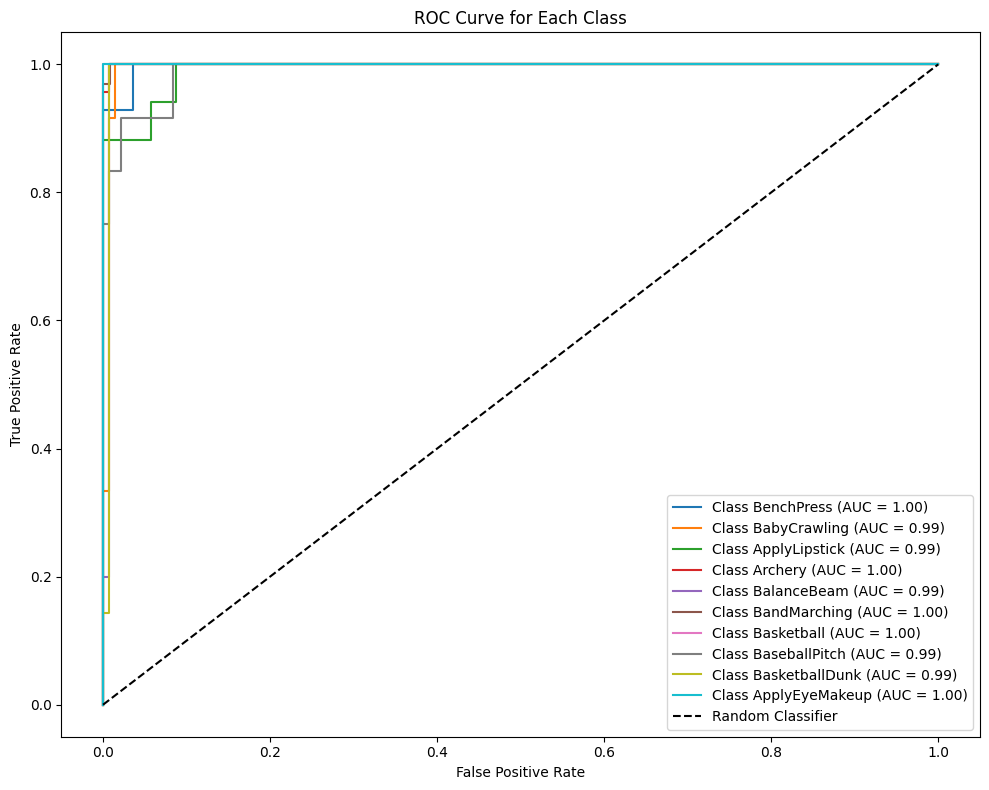

In [34]:
from sklearn.metrics import roc_curve, auc

from sklearn.preprocessing import label_binarize
import numpy as np

true_labels_bin = label_binarize(true_labels, classes=np.arange(len(label_name)))

fpr = {}
tpr = {}
roc_auc = {}

pred_probs = predictions

for i in range(len(label_name)):
    fpr[i], tpr[i], _ = roc_curve(true_labels_bin[:, i], pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(len(label_name)):
    plt.plot(fpr[i], tpr[i], label=f'Class {label_name[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

plt.title('ROC Curve for Each Class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


# precision Recall Curve

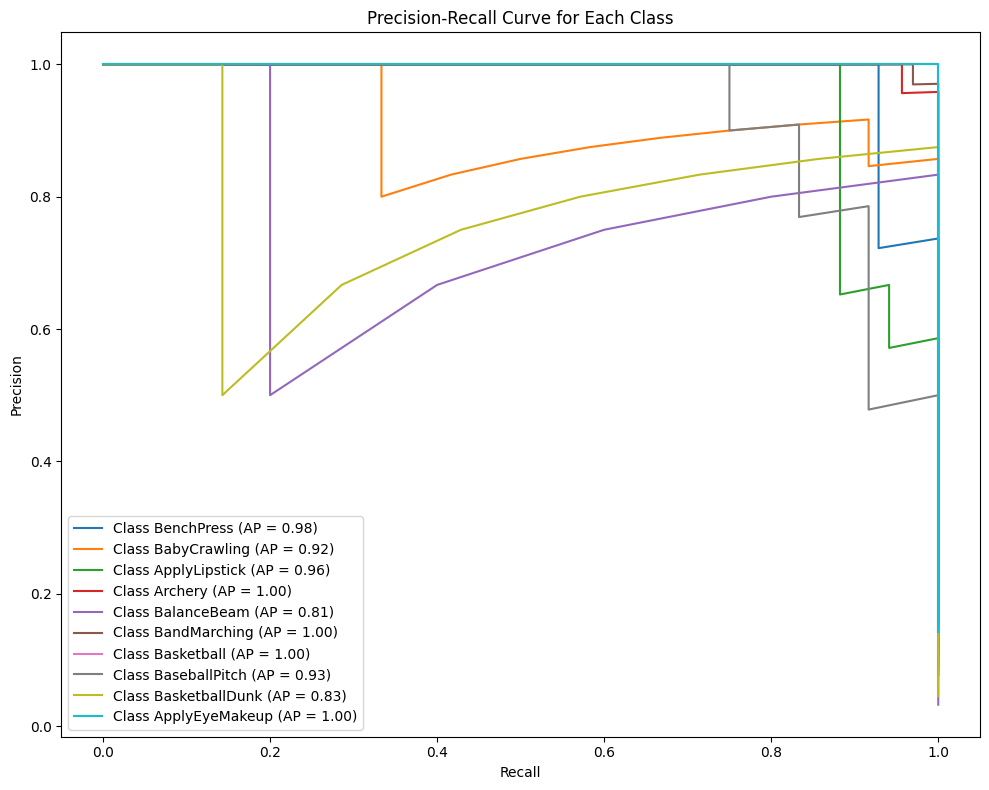

In [35]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

precision = {}
recall = {}
avg_precision = {}

for i in range(len(label_name)):
    precision[i], recall[i], _ = precision_recall_curve(true_labels_bin[:, i], pred_probs[:, i])
    avg_precision[i] = average_precision_score(true_labels_bin[:, i], pred_probs[:, i])

plt.figure(figsize=(10, 8))
for i in range(len(label_name)):
    plt.plot(recall[i], precision[i], label=f'Class {label_name[i]} (AP = {avg_precision[i]:.2f})')

plt.title('Precision-Recall Curve for Each Class')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


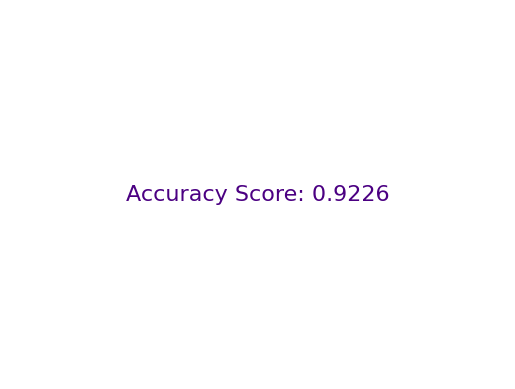

In [36]:
accuracy = accuracy_score(true_labels,predicted_class)
plt.plot([])
plt.text(0, 0, f'Accuracy Score: {accuracy:.4f}', fontsize=16, ha='center', va='center', color="indigo")
plt.axis('off')
plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.show()

# Roc Auc Score

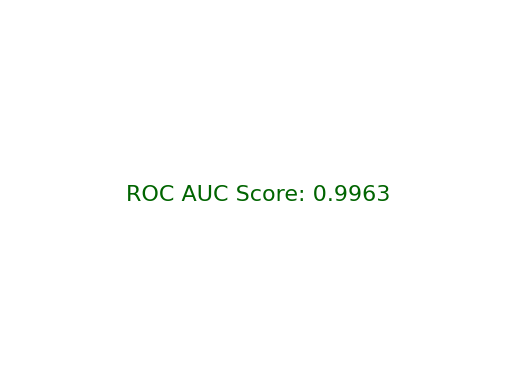

In [37]:

n_classes = predictions.shape[1]
true_labels_binarized = label_binarize(true_labels, classes=np.arange(n_classes))
roc_auc = roc_auc_score(true_labels_binarized, pred_probs, multi_class='ovr', average='macro')


plt.text(0, 0, f'ROC AUC Score: {roc_auc:.4f}', 
         fontsize=16, ha='center', va='center', color="darkgreen")
plt.axis('off')
plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.show()


# Custom Data Prediction

In [38]:
from pytorchvideo.data.encoded_video import EncodedVideo

def load_video(video_path):
   video = EncodedVideo.from_path(video_path)
   video_data = video.get_clip(start_sec=0, end_sec=video.duration)
   return video_data['video']

def preprocess_video(video_frames):
   transform_temporal = UniformTemporalSubsample(16)
   video_frames = transform_temporal(video_frames)
   video_frames = video_frames / 255.0
   if video_frames.shape[0] == 3:
       video_frames = video_frames.permute(1, 0, 2, 3)
   mean = torch.tensor([0.485, 0.456, 0.406])
   std = torch.tensor([0.229, 0.224, 0.225])
   for t in range(video_frames.shape[0]):
       video_frames[t] = (video_frames[t] - mean[:, None, None]) / std[:, None, None]
   resize_transform = Resize((224, 224))
   video_frames = resize_transform(video_frames)
   video_frames = video_frames.unsqueeze(0)
   return video_frames

def predict_video(video_path, model, device):
   video = load_video(video_path)
   processed_video = preprocess_video(video)
   processed_video = processed_video.to(device)
   with torch.no_grad():
       outputs = model(processed_video)
       logits = outputs.logits
       predicted_class_idx = logits.argmax(-1).item()
       probabilities = torch.nn.functional.softmax(logits, dim=-1)
       confidence = probabilities[0][predicted_class_idx].item()
   class_name = label_name[predicted_class_idx]
   return class_name, confidence

video_path = "/kaggle/working/UCF101_subset/test/ApplyEyeMakeup/v_ApplyEyeMakeup_g03_c01.avi"
predicted_class, confidence = predict_video(video_path, loaded_model, device)
print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.2%}")

def get_top_k_predictions(video_path, model, device, k=3):
   video = load_video(video_path)
   processed_video = preprocess_video(video)
   processed_video = processed_video.to(device)
   with torch.no_grad():
       outputs = model(processed_video)
       logits = outputs.logits
       probabilities = torch.nn.functional.softmax(logits, dim=-1)[0]
       top_k = torch.topk(probabilities, k)
       print(f"\nTop {k} predictions:")
       for i in range(k):
           idx = top_k.indices[i].item()
           prob = top_k.values[i].item()
           print(f"{i+1}. {label_name[idx]}: {prob:.2%}")

get_top_k_predictions(video_path, loaded_model, device, k=3)

Predicted class: BenchPress
Confidence: 78.17%

Top 3 predictions:
1. BenchPress: 78.17%
2. BabyCrawling: 18.85%
3. BandMarching: 0.51%


In [39]:
! pip install gradio

/usr/lib/python3.10/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [ ]:
import gradio as gr
import torch
from pytorchvideo.data.encoded_video import EncodedVideo
from torchvision.transforms import Resize
from pytorchvideo.transforms import UniformTemporalSubsample
from transformers import VideoMAEForVideoClassification

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_path = "/kaggle/working/video_classifier_new"
loaded_model = VideoMAEForVideoClassification.from_pretrained(model_path)
loaded_model = loaded_model.to(device)
loaded_model.eval()

label_names = [
    'Archery', 'BalanceBeam', 'BenchPress', 'ApplyEyeMakeup', 'BasketballDunk',
    'BandMarching', 'BabyCrawling', 'ApplyLipstick', 'BaseballPitch', 'Basketball'
]

def load_video(video_path):
    video = EncodedVideo.from_path(video_path)
    video_data = video.get_clip(start_sec=0, end_sec=video.duration)
    return video_data['video']

def preprocess_video(video_frames):
    transform_temporal = UniformTemporalSubsample(16)
    video_frames = transform_temporal(video_frames)
    video_frames = video_frames / 255.0
    if video_frames.shape[0] == 3:
        video_frames = video_frames.permute(1, 0, 2, 3)
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    for t in range(video_frames.shape[0]):
        video_frames[t] = (video_frames[t] - mean[:, None, None]) / std[:, None, None]
    resize_transform = Resize((224, 224))
    video_frames = resize_transform(video_frames)
    video_frames = video_frames.unsqueeze(0)
    return video_frames

def predict_video(video):
    try:
        video_path = video  # The path is directly passed as a string
        video_data = load_video(video_path)
        processed_video = preprocess_video(video_data)
        processed_video = processed_video.to(device)
        
        with torch.no_grad():
            outputs = loaded_model(processed_video)
            logits = outputs.logits
            probabilities = torch.nn.functional.softmax(logits, dim=-1)[0]
            top_3 = torch.topk(probabilities, 3)
            
        results = []
        for i in range(3):
            idx = top_3.indices[i].item()
            prob = top_3.values[i].item()
            results.append(f"{label_names[idx]}: {prob:.2%}")
            
        return "\n".join(results)
    except Exception as e:
        return f"Error processing video: {str(e)}"

iface = gr.Interface(
    fn=predict_video,
    inputs=gr.Video(label="Upload Video"),
    outputs=gr.Textbox(label="Top 3 Predictions"),
    title="Video Action Recognition",
    description="Upload a video to classify the action being performed. Model will return top 3 predictions.",
    examples=[
        ["/kaggle/working/UCF101_subset/train/Archery/v_Archery_g03_c02.avi"],
        ["/kaggle/working/UCF101_subset/train/BaseballPitch/v_BaseballPitch_g01_c02.avi"],
        ["/kaggle/working/UCF101_subset/train/BabyCrawling/v_BabyCrawling_g01_c03.avi"]
    ]
)

iface.launch(debug=True, share=True)


/usr/local/lib/python3.10/dist-packages/gradio/components/video.py:340: UserWarning: Video does not have browser-compatible container or codec. Converting to mp4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/gradio/components/video.py:340: UserWarning: Video does not have browser-compatible container or codec. Converting to mp4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/gradio/components/video.py:340: UserWarning: Video does not have browser-compatible container or codec. Converting to mp4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/gradio/components/video.py:340: UserWarning: Video does not have browser-compatible container or codec. Converting to mp4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/gradio/components/video.py:340: UserWarning: Video does not have browser-compatible container or codec. Converting to mp4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/gradio/components/video.py:340: UserWarning: Video does not 

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://03993a3929b87df5aa.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.10/dist-packages/gradio/components/video.py:340: UserWarning: Video does not have browser-compatible container or codec. Converting to mp4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/gradio/components/video.py:340: UserWarning: Video does not have browser-compatible container or codec. Converting to mp4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/gradio/components/video.py:340: UserWarning: Video does not have browser-compatible container or codec. Converting to mp4.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/gradio/components/video.py:340: UserWarning: Video does not have browser-compatible container or codec. Converting to mp4.
  warnings.warn(
